In [1]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import urllib3

# Set the current and parent paths
current_path = os.getcwd()
parent_path = os.path.dirname(current_path)
sys.path.append(parent_path)

# Configure matplotlib style
plt.style.use('tableau-colorblind10')

# Import custom modules
import funcTidal  # Module for acquiring tidal data from NOAA
import funcRotor  # Module for acquiring rotor data
import funcSimRotor  # Module for simulating rotor dynamics

import constUnitConvert
import constGlobal

# Initialize constants and unit conversion
CONVERT = constUnitConvert.ConstantsUnitConversion()
GLOBAL = constGlobal.ConstantsGlobal()

# Disable the InsecureRequestWarning
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)


# Rotor Simulation Guide

This guide walks users through the process of performing a rotor simulation.

## Step 1: Load Tidal Data

The first step in the simulation process is to load the tidal data. This data is essential for understanding the environmental conditions under which the rotor will operate.

Mooring depth is 31.1 [m].
Cable length is 2.46 miles and the closest city is Anchorage.


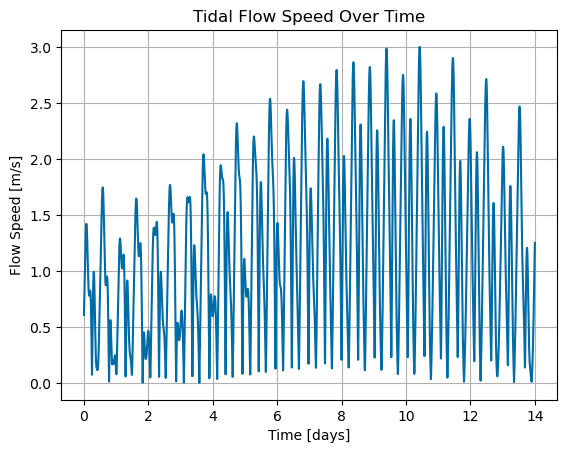

In [2]:
# Define parameters for tidal data acquisition
station = "COI0303"  # Must be string; Harmonic stations only; https://tidesandcurrents.noaa.gov/noaacurrents/Stations?g=693
startdate = 20210901  # yyyyMMdd
rangeHr = 2 * 7 * 24  # Two weeks
timestep = 0.25  # One second

# Load tidal data using the funcTidal module
Uinf, t, dMoor, buoyLatitude, buoyLongitude = funcTidal.loadTidal(station, startdate, rangeHr, timestep)

# Print the mooring depth
print(f'Mooring depth is {dMoor} [m].')

# Define the path to the Alaska city location data
AlaskaCityLocationData = "../../TurboShipCostCalculator/AlaskaCityLatLong.txt"

# Calculate the cable length and closest city
dCable, CityName = funcTidal.calCableLen(buoyLatitude, buoyLongitude, AlaskaCityLocationData)

# Print the cable length and closest city
print(f'Cable length is {round(dCable * CONVERT.m2mile, 2)} miles and the closest city is {CityName}.')

# Plot the flow speed over time
plt.plot(t * CONVERT.sec2days, Uinf)
plt.xlabel('Time [days]')
plt.ylabel('Flow Speed [m/s]')
plt.title('Tidal Flow Speed Over Time')
plt.grid(True)
plt.show()


## Step 2: Load Rotor Data

Next, we load the rotor data. This data include information about the rotor's performance characteristics and moment of inertia.


In [3]:
# Define the path to the AeroDyn folder
AeroDynFolderPath = "../../TurboShipCostCalculator/Original_MHKF1_ARLScaled_20Sections_5ms_VariedPitch_Cp/"

# Define the maximum and minimum Tip Speed Ratio (TSR)
myTSRmax = 10.0
myTSRmin = 0.0

# Load rotor surfaces
CpFunc, CtFunc, CpminFunc, spanRatio, CpOpt, TSROpt = funcRotor.loadRotorSurfaces(AeroDynFolderPath, myTSRmax, myTSRmin)

# Estimate rotor mass
bladeVolume, bladeMass, bladeRadius, bladeCoordinate = funcRotor.estimateRotorMass(AeroDynFolderPath)


<font color='red'>Note: This section of code may take a while to run as it simulates the rotor dynamics.</font>

## Step 3: Simulate Rotor Dynamics

To perform the rotor simulation, the following information must be specified:

- **Rotor Parameters**: Rotor radius, generator power rating, hub depth, minimum cut-in speed, and whether brakes are used.
- **Tidal Data**: `Uinf`, `t`, and `dMoor` from the `funcTidal.loadTidal()` output.
- **Rotor Performance Data**: `CpFunc`, `CtFunc`, `CpOpt`, and `TSROpt` from the `funcRotor.loadRotorSurfaces()` output.
- **Rotor Mass Data**: `bladeRadius` and `bladeMass` from the `funcRotor.estimateRotorMass()` output.


In [4]:
# Define parameters for rotor simulation
Radius = 1.0  # Rotor radius in meters
Prated = 15.0e3  # Rated power in watts
dHub = 2.0  # Hub depth in meters
Umin = 0.1  # Cut-in speed in m/s
withBrake = True  # Whether to include brake in the simulation

# Simulate rotor dynamics using the funcSimRotor module
w, Tc, Pmech, Pelec, Phydro, Pfluid, Punc, TSR, Ft, Th = funcSimRotor.simRotor(
    Radius, Prated, dHub, dMoor, Uinf, t, CpFunc, CtFunc, CpOpt, TSROpt, bladeRadius, bladeMass, Umin, withBrake
)


Running rotor simulation for Radius = 1.0, Prated = 15000.0, dHub = 2.0.


# Printing and Plotting Rotor Simulation Results

In this section, we will demonstrate how to print the statistics of the rotor simulation and plot the time domain results using built-in functions.

## Printing Simulation Statistics

The built-in function `funcSimRotor.printSimRotorStatistic` can be used to print detailed statistics of the rotor simulation.

## Plotting Time Domain Results

The built-in function `funcSimRotor.plotTimeDomainResult` can be used to plot the time domain results of the rotor simulation. 

- **VESSEL Information**: The `VESSEL` parameter is used for saving the output figure. If inapplicable, you can set it to `None`.


Rotor Dynamics (Mean) [SI units are assumed]:
w: 5.05
Tc: 314.38
TSR: 4.19
Pmech: 2594.65
Pelec: 2335.18
Phydro: 2612.84
Pfluid: 6022.86
Punc: 2639.14
Ft: 2568.61
Th: 316.68
Rotor Dynamics (Max) [SI units are assumed]:
w: 12.95
Tc: 1599.16
TSR: 5.12
Pmech: 16666.67
Pelec: 15000.00
Phydro: 18930.38
Pfluid: 43632.41
Punc: 19119.17
Ft: 11978.42
Th: 1461.54


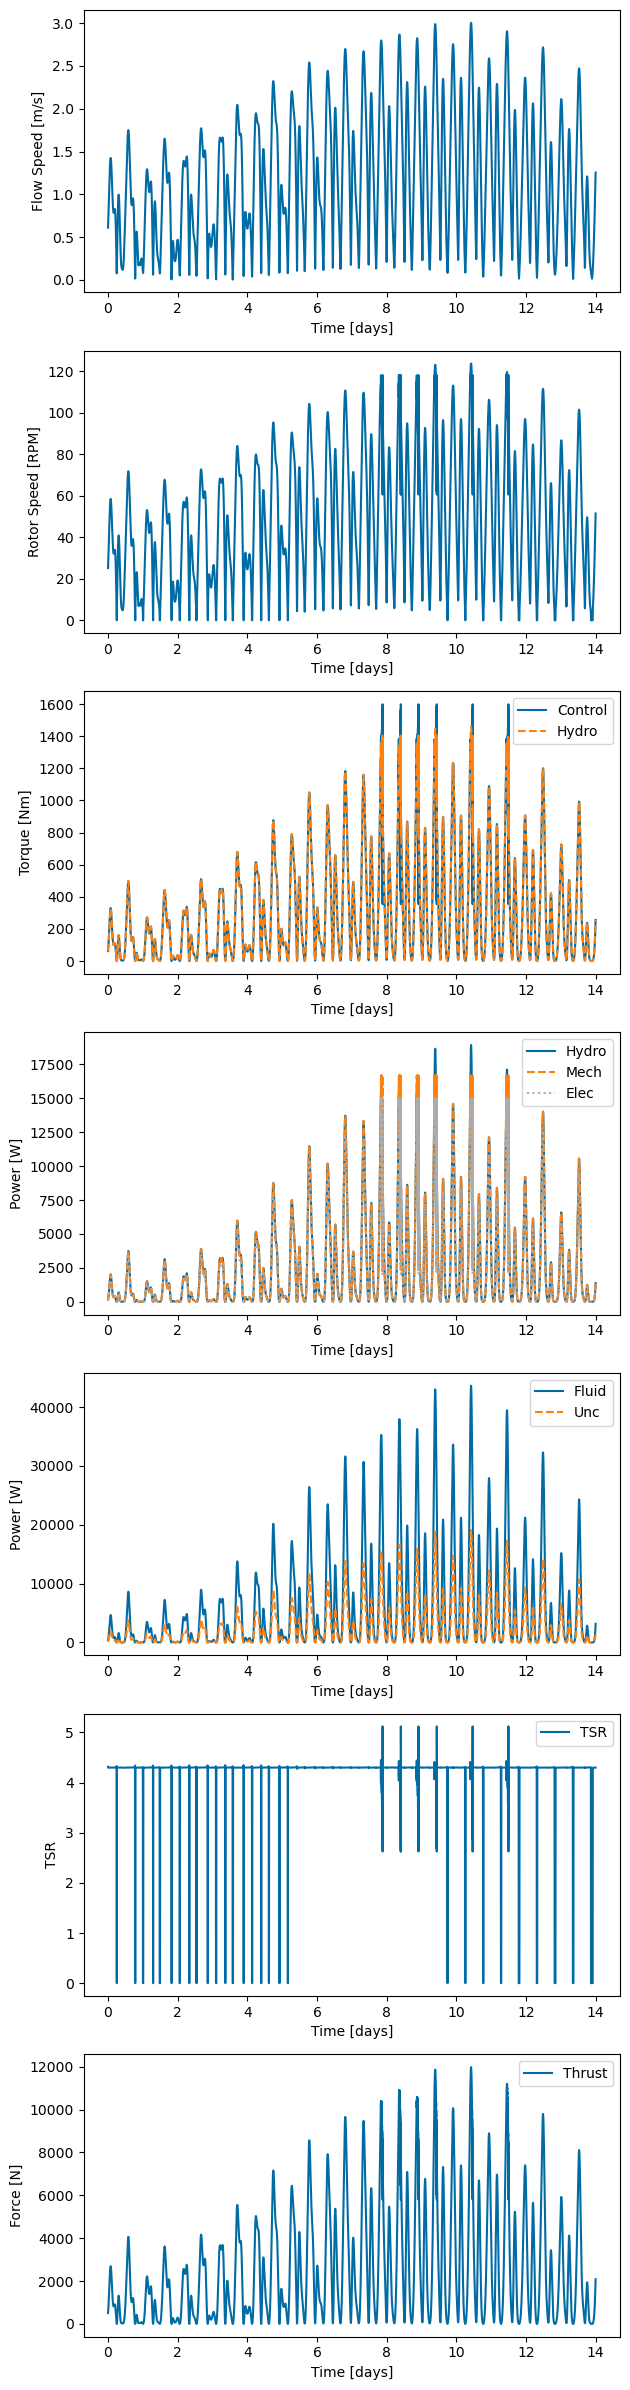

In [5]:
# Print simulation statistics
funcSimRotor.printSimRotorStatistic(w, Tc, Pmech, Pelec, Phydro, Pfluid, Punc, TSR, Ft, Th)

# Plot time domain results
funcSimRotor.plotTimeDomainResult(Uinf, t, w, Tc, Pmech, Pelec, Phydro, Pfluid, Punc, TSR, Ft, Th, station, startdate, None, Umin, withBrake)


## Checking Vessel Pitch Constraint

Using the simulation data, we can determine if the vessel pitch constraint would be violated. Follow these steps:

1. **Load Vessel Properties**: 
   - First, load the vessel properties from `constVessel`. 
   - In this example, we use the fishing vessel data available by default.

2. **Update Flow Speed**: 
   - Adjust the flow speed according to the hub depth.
   - Calculate the mooring thrust force and the turbine thrust force.

3. **Specify Number of Turbines**: 
   - Indicate the number of turbines you want to fit on your vessel.


In [6]:
import constVessel
import funcConstraint

# Define the vessel type
VESSEL = constVessel.FISH

# Define the number of turbines
NumTurbine = 3

# Update flow speed at depth
Uinf_update = funcTidal.flowAtDepth(Uinf, Radius, dHub, dMoor)

# Calculate vessel thrust force
F_vessel_thrust = funcConstraint.calForceMoorThrustFunc(Uinf_update, VESSEL)

# Calculate turbine thrust force
F_turbine_thrust = funcSimRotor.calForceThrustFunc(Radius, Uinf_update, CtFunc(TSR))


# Plotting the Vessel Pitch Constraint

This section demonstrates how to plot the vessel pitch constraint using the `funcConstraint` module.


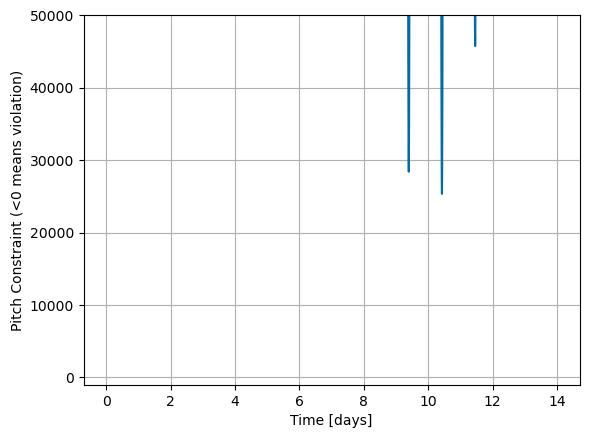

In [7]:
# Define y-axis limits for plotting
ylim = [-1000, 50000]

# Plot the pitch constraint
funcConstraint.plotPitchCon(Radius, dHub, dMoor, Uinf, CtFunc, TSR, VESSEL, NumTurbine, t, ylim)


# Plotting the Cavitation Constraint

This section demonstrates how to plot the cavitation constraint using the `funcConstraint` module.


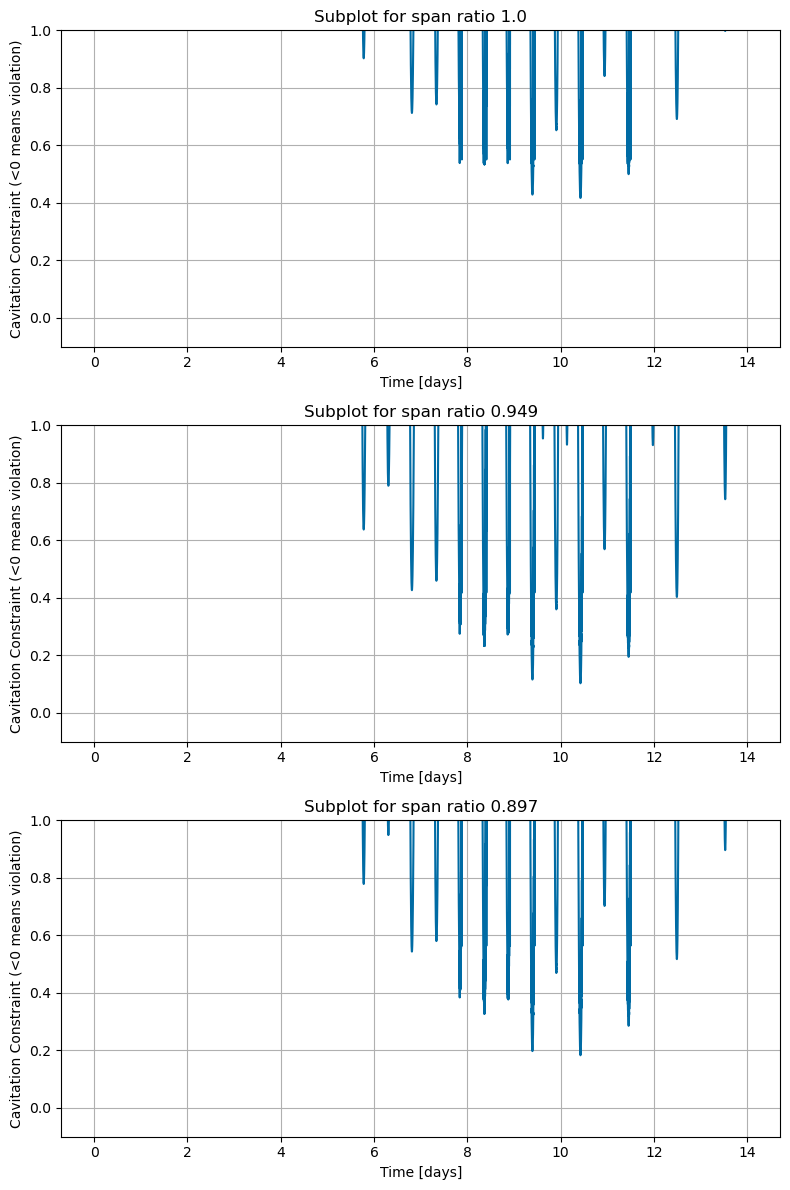

In [8]:
# Define y-axis limits for plotting (None means auto-scaling)
ylim = None

# Plot the cavitation constraint
funcConstraint.plotCavitationCon(Radius, dHub, dMoor, Uinf, w, TSR, CpminFunc, spanRatio, t, ylim)


# Calculating and Printing the Levelized Cost of Energy (LCOE)

This section demonstrates how to calculate the Levelized Cost of Energy (LCOE) and print the cost breakdown using the `funcLCOE` module.



In [9]:
import funcLCOE

# Calculate the Levelized Cost of Energy (LCOE) and cost breakdown
LCOE, CostBreakdown = funcLCOE.calculate_cost(Radius, Prated, NumTurbine, dCable, dMoor, F_vessel_thrust, F_turbine_thrust, Pelec, t)

# Print the cost breakdown
funcLCOE.printCostBreakdown(CostBreakdown)


Cost Breakdown:
LCOE: $0.55
CAPEX: $215841.75
Et: $61412.90
cable: $59911.14
grid connect: $1281.87
moor: $5420.16
blade: $409.46
generator: $14543.25
misc: $2115.09
hub: $9485.86
cable install: $112396.73
